# 1. 데이터 시각화, 프로젝트 I = 미세먼지 데이터 분석 

## a. 미세먼지 데이터 🥫
---
- 미세먼지 데이터 수집
    1. 에어코리아 사이트에서 직접다운받는 방법
        - https://www.airkorea.or.kr/index
        - 메뉴 > 통계정보 > 최종확정자료다운로드 > 확정자료다운로드 > 날짜선택
    2. read_excel 이용
       - https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/dust.xlsx

- 패키지 임포트 --> 데이터 수집 --> 데이터프레임 --> 확인 = 3총사 (직접, info, describe)

In [2]:
!pip install xlrd # 구버전 엑셀파일 읽기위한 패키지
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dust = pd.read_excel('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/dust.xlsx')
dust.head()


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


,날짜,시도,측정소명,측정소코드,아황산가스,일산화탄소,오존,이산화질소,PM10,PM2.5
0,2023-01-01 01,서울 강남구,강남구,111261,0.004,0.9,0.003,0.051,51.0,37.0
1,2023-01-01 02,서울 강남구,강남구,111261,0.004,0.9,0.003,0.050,70.0,53.0
2,2023-01-01 03,서울 강남구,강남구,111261,0.004,0.7,0.009,0.039,73.0,53.0
3,2023-01-01 04,서울 강남구,강남구,111261,0.003,0.8,0.007,0.043,76.0,56.0
4,2023-01-01 05,서울 강남구,강남구,111261,0.004,0.7,0.018,0.026,82.0,59.0


In [3]:
dust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      744 non-null    object 
 1   시도      744 non-null    object 
 2   측정소명    744 non-null    object 
 3   측정소코드   744 non-null    int64  
 4   아황산가스   740 non-null    float64
 5   일산화탄소   740 non-null    float64
 6   오존      740 non-null    float64
 7   이산화질소   740 non-null    float64
 8   PM10    741 non-null    float64
 9   PM2.5   741 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 58.3+ KB


In [4]:
dust.describe()

,측정소코드,아황산가스,일산화탄소,오존,이산화질소,PM10,PM2.5
count,744.0,740.000000,740.000000,740.000000,740.000000,741.000000,741.000000
mean,111261.0,0.003245,0.538662,0.016688,0.030711,46.379217,24.983806
std,0.0,0.000632,0.207093,0.010916,0.015688,31.426500,20.291251
min,111261.0,0.002000,0.240000,0.002200,0.004800,3.000000,1.000000
25%,111261.0,0.002800,0.380000,0.005975,0.018250,24.000000,11.000000
50%,111261.0,0.003200,0.490000,0.016000,0.028850,35.000000,18.000000
75%,111261.0,0.003700,0.670000,0.026325,0.041900,60.000000,33.000000
max,111261.0,0.006400,1.270000,0.043500,0.086500,160.000000,117.000000


- 일단 필요 없는 열 버리기

In [5]:
dust = dust.drop(['시도', '측정소명', '측정소코드'], axis=1)
dust

,날짜,아황산가스,일산화탄소,오존,이산화질소,PM10,PM2.5
0,2023-01-01 01,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...
739,2023-01-31 20,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23,0.0030,0.35,0.0401,0.0175,49.0,19.0


- 열이름 영문으로 변경

In [6]:
dust.rename(columns={'날짜':'date',	'아황산가스':'so2', '일산화탄소':'co', '오존':'o3', '이산화질소':'no2'}, inplace=True)
dust

,date,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...
739,2023-01-31 20,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23,0.0030,0.35,0.0401,0.0175,49.0,19.0


- date열 형변환 --> 데이트타임타입

In [7]:
dust['date']= pd.to_datetime(dust['date'], format='%Y-%m-%d %H')
dust.dtypes

ValueError: unconverted data remains when parsing with format "%Y-%m-%d %H": "4", at position 23. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

- datetime의 H는 0~23이여야함 --> 리스트 컴프리헨션으로 변환 

In [8]:
dust.date = [a.split(' ')[0] + ' 00' if a.split(' ')[1] == '24' else a for a in dust.date]

- 여기서 하나 외웁시다. = 데이트타임 형식으로 변환해보자~

In [9]:
dust['date']= pd.to_datetime(dust['date'], format='%Y-%m-%d %H')
dust.dtypes

date     datetime64[ns]
so2             float64
co              float64
o3              float64
no2             float64
PM10            float64
PM2.5           float64
dtype: object

- 각각 year, month, day 분리

In [10]:
dust['year'] = dust['date'].dt.year
dust['month'] = dust['date'].dt.month
dust['day'] = dust['date'].dt.day
dust = dust[['date', 'year', 'month', 'day', 'so2', 'co', 'o3', 'no2', 'PM10', 'PM2.5']] # 보기좋게 재정렬
dust.columns

Index(['date', 'year', 'month', 'day', 'so2', 'co', 'o3', 'no2', 'PM10',
       'PM2.5'],
      dtype='object')

In [11]:
dust.dtypes

date     datetime64[ns]
year              int32
month             int32
day               int32
so2             float64
co              float64
o3              float64
no2             float64
PM10            float64
PM2.5           float64
dtype: object

- 년, 월, 일 --> int형으로 변환

In [12]:
dust['year'] = dust['date'].dt.year.astype(int)
dust['month'] = dust['date'].dt.month.astype(int)
dust['day'] = dust['date'].dt.day.astype(int)
dust = dust[['date', 'year', 'month', 'day', 'so2', 'co', 'o3', 'no2', 'PM10', 'PM2.5']] # 보기좋게 재정렬
dust.columns

Index(['date', 'year', 'month', 'day', 'so2', 'co', 'o3', 'no2', 'PM10',
       'PM2.5'],
      dtype='object')

In [13]:
dust.dtypes

date     datetime64[ns]
year              int64
month             int64
day               int64
so2             float64
co              float64
o3              float64
no2             float64
PM10            float64
PM2.5           float64
dtype: object

- 본격적으로 결측치 삭제 --> info에서 확인했었죠?

In [14]:
dust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    744 non-null    datetime64[ns]
 1   year    744 non-null    int64         
 2   month   744 non-null    int64         
 3   day     744 non-null    int64         
 4   so2     740 non-null    float64       
 5   co      740 non-null    float64       
 6   o3      740 non-null    float64       
 7   no2     740 non-null    float64       
 8   PM10    741 non-null    float64       
 9   PM2.5   741 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 58.3 KB


In [15]:
dust.isna().sum()

date     0
year     0
month    0
day      0
so2      4
co       4
o3       4
no2      4
PM10     3
PM2.5    3
dtype: int64

- 리스트 컴프리헨션을 써도 되고 = df.apply(람다식 --> 열을 순서대로 가져와서 변경)를 써도 됩니다.

In [16]:
pd.DataFrame({a:dust[a].fillna(dust[a].mean()) for a in dust.columns}) # but 다시 데이터프레임으로 담아줘야 해서 귀찮다...

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


In [17]:
pd.DataFrame({a:dust[a].fillna(dust[a].mean()) for a in dust.columns}).isnull().sum()

date     0
year     0
month    0
day      0
so2      0
co       0
o3       0
no2      0
PM10     0
PM2.5    0
dtype: int64

In [18]:
pd.DataFrame({a:dust[a].fillna(dust[a].mean()) for a in dust.columns}).dtypes

date     datetime64[ns]
year              int64
month             int64
day               int64
so2             float64
co              float64
o3              float64
no2             float64
PM10            float64
PM2.5           float64
dtype: object

In [19]:
tmp1 = pd.DataFrame({a:dust[a].fillna(dust[a].mean()) for a in dust.columns})
tmp1

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


In [20]:
dust.apply(lambda x: x.fillna(x.mean())) # 이게 짧긴 하네요...

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


In [21]:
dust.apply(lambda x: x.fillna(x.mean())).isnull().sum() 

date     0
year     0
month    0
day      0
so2      0
co       0
o3       0
no2      0
PM10     0
PM2.5    0
dtype: int64

In [22]:
tmp2 = dust.apply(lambda x: x.fillna(x.mean()))
tmp2

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


In [23]:
dust = tmp1
dust.isna().sum()

date     0
year     0
month    0
day      0
so2      0
co       0
o3       0
no2      0
PM10     0
PM2.5    0
dtype: int64

In [24]:
dust

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


## b. 날씨 🌨️
---
- 날씨 데이터 수집
    1. 기상청 사이트에서 직접다운받는 방법
        - https://data.kma.go.kr/cmmn/main.do
        - 데이터 > 기상 > 방재기상관측(AWS) > 파일셋 > 지역선택 > 기간선택
    2. read_csv 이용
       - https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/weathers.csv

In [25]:
weather = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/weathers.csv')
weather.head()

,지점,일시,기온(°C),풍향(deg),풍속(m/s),강수량(mm),현지기압(hPa),해면기압(hPa),습도(%),일사(MJ/m^2),일조(hr)
0,400,2023-01-01 0:00,-0.5,95.6,0.6,0.0,NaN,NaN,71.5,NaN,NaN
1,400,2023-01-01 1:00,0.3,99.9,1.0,0.0,NaN,NaN,68.1,NaN,NaN
2,400,2023-01-01 2:00,-0.1,0.0,0.4,0.0,NaN,NaN,71.7,NaN,NaN
3,400,2023-01-01 3:00,0.0,0.0,0.3,0.0,NaN,NaN,74.8,NaN,NaN
4,400,2023-01-01 4:00,0.5,0.0,0.4,0.0,NaN,NaN,74.7,NaN,NaN


- 알아보기 3총사

In [26]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8752 entries, 0 to 8751
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   지점          8752 non-null   int64  
 1   일시          8752 non-null   object 
 2   기온(°C)      8746 non-null   float64
 3   풍향(deg)     8672 non-null   float64
 4   풍속(m/s)     8676 non-null   float64
 5   강수량(mm)     8680 non-null   float64
 6   현지기압(hPa)   0 non-null      float64
 7   해면기압(hPa)   0 non-null      float64
 8   습도(%)       8746 non-null   float64
 9   일사(MJ/m^2)  4386 non-null   float64
 10  일조(hr)      4386 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 752.3+ KB


In [27]:
weather.describe()

,지점,기온(°C),풍향(deg),풍속(m/s),강수량(mm),현지기압(hPa),해면기압(hPa),습도(%),일사(MJ/m^2),일조(hr)
count,8752.0,8746.000000,8672.000000,8676.000000,8680.000000,0.0,0.0,8746.000000,4386.0,4386.0
mean,400.0,14.560782,170.441109,1.168799,0.177995,NaN,NaN,62.394695,0.0,0.0
std,0.0,10.951458,118.850217,0.805208,1.174022,NaN,NaN,21.597574,0.0,0.0
min,400.0,-16.200000,0.000000,0.000000,0.000000,NaN,NaN,9.600000,0.0,0.0
25%,400.0,5.500000,58.850000,0.600000,0.000000,NaN,NaN,46.200000,0.0,0.0
50%,400.0,15.900000,181.650000,1.000000,0.000000,NaN,NaN,62.800000,0.0,0.0
75%,400.0,23.900000,272.200000,1.600000,0.000000,NaN,NaN,80.200000,0.0,0.0
max,400.0,36.900000,360.000000,4.900000,34.000000,NaN,NaN,99.700000,0.0,0.0


- 일단 필요없는 열 삭제

In [28]:
weather.drop(['지점', '풍향(deg)', '현지기압(hPa)', '해면기압(hPa)', '일사(MJ/m^2)', '일조(hr)'], axis=1, inplace=True)
weather

,일시,기온(°C),풍속(m/s),강수량(mm),습도(%)
0,2023-01-01 0:00,-0.5,0.6,0.0,71.5
1,2023-01-01 1:00,0.3,1.0,0.0,68.1
2,2023-01-01 2:00,-0.1,0.4,0.0,71.7
3,2023-01-01 3:00,0.0,0.3,0.0,74.8
4,2023-01-01 4:00,0.5,0.4,0.0,74.7
...,...,...,...,...,...
8747,2023-12-31 19:00,1.4,0.0,NaN,92.1
8748,2023-12-31 20:00,0.8,0.5,NaN,95.3
8749,2023-12-31 21:00,0.4,0.1,NaN,96.2
8750,2023-12-31 22:00,0.0,0.1,NaN,97.1


- 컬럼이름 바꾸기

In [29]:
weather.columns=['date','temp', 'wind','rain','humid']
weather.columns

Index(['date', 'temp', 'wind', 'rain', 'humid'], dtype='object')

- date 컬럼 형식 변경 --> 데이트타임형 식으로

In [30]:
weather['date'] = pd.to_datetime(weather['date'])
weather.head()

,date,temp,wind,rain,humid
0,2023-01-01 00:00:00,-0.5,0.6,0.0,71.5
1,2023-01-01 01:00:00,0.3,1.0,0.0,68.1
2,2023-01-01 02:00:00,-0.1,0.4,0.0,71.7
3,2023-01-01 03:00:00,0.0,0.3,0.0,74.8
4,2023-01-01 04:00:00,0.5,0.4,0.0,74.7


- 결측치 확인

In [31]:
weather.isnull().sum()

date      0
temp      6
wind     76
rain     72
humid     6
dtype: int64

In [32]:
weather = weather.apply(lambda x: x.fillna(method='ffill'))

C:\Users\tysep16\AppData\Local\Temp\ipykernel_9692\1107727007.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather = weather.apply(lambda x: x.fillna(method='ffill'))


- 데이터전처리 --> 결측치 재확인

In [33]:
weather.isnull().sum()

date     0
temp     0
wind     0
rain     0
humid    0
dtype: int64

In [34]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8752 entries, 0 to 8751
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8752 non-null   datetime64[ns]
 1   temp    8752 non-null   float64       
 2   wind    8752 non-null   float64       
 3   rain    8752 non-null   float64       
 4   humid   8752 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 342.0 KB


## c. 데이터 병합하기 --> 분석하기 --> 시각화하기 🏞️
---
- 각 데이터프레임의 형태를 확인 후 --> date 기준으로 병합!

In [35]:
dust.shape, weather.shape

((744, 10), (8752, 5))

In [36]:
dust

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0
...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0


In [37]:
weather

,date,temp,wind,rain,humid
0,2023-01-01 00:00:00,-0.5,0.6,0.0,71.5
1,2023-01-01 01:00:00,0.3,1.0,0.0,68.1
2,2023-01-01 02:00:00,-0.1,0.4,0.0,71.7
3,2023-01-01 03:00:00,0.0,0.3,0.0,74.8
4,2023-01-01 04:00:00,0.5,0.4,0.0,74.7
...,...,...,...,...,...
8747,2023-12-31 19:00:00,1.4,0.0,0.0,92.1
8748,2023-12-31 20:00:00,0.8,0.5,0.0,95.3
8749,2023-12-31 21:00:00,0.4,0.1,0.0,96.2
8750,2023-12-31 22:00:00,0.0,0.1,0.0,97.1


In [38]:
df = pd.merge(dust, weather, on='date', how='left')
df

,date,year,month,day,so2,co,o3,no2,PM10,PM2.5,temp,wind,rain,humid
0,2023-01-01 01:00:00,2023,1,1,0.0040,0.90,0.0030,0.0510,51.0,37.0,0.3,1.0,0.0,68.1
1,2023-01-01 02:00:00,2023,1,1,0.0040,0.90,0.0030,0.0500,70.0,53.0,-0.1,0.4,0.0,71.7
2,2023-01-01 03:00:00,2023,1,1,0.0040,0.70,0.0090,0.0390,73.0,53.0,0.0,0.3,0.0,74.8
3,2023-01-01 04:00:00,2023,1,1,0.0030,0.80,0.0070,0.0430,76.0,56.0,0.5,0.4,0.0,74.7
4,2023-01-01 05:00:00,2023,1,1,0.0040,0.70,0.0180,0.0260,82.0,59.0,2.0,1.2,0.0,59.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,2023-01-31 20:00:00,2023,1,31,0.0034,0.38,0.0402,0.0172,38.0,14.0,7.3,2.4,0.0,66.6
740,2023-01-31 21:00:00,2023,1,31,0.0037,0.43,0.0388,0.0194,42.0,16.0,7.1,2.2,0.0,71.0
741,2023-01-31 22:00:00,2023,1,31,0.0036,0.34,0.0435,0.0152,41.0,16.0,6.9,1.8,0.0,73.9
742,2023-01-31 23:00:00,2023,1,31,0.0030,0.35,0.0401,0.0175,49.0,19.0,6.9,1.3,0.0,77.3


- groupby day 기준으로 집계함수 평균을 구해보자.

In [39]:
df.groupby(by='day').mean()

,date,year,month,so2,co,o3,no2,PM10,PM2.5,temp,wind,rain,humid
day,,,,,,,,,,,,,
1,2023-01-01 11:30:00,2023.0,1.0,0.003792,0.608333,0.023917,0.023917,52.125000,35.750000,0.937500,1.525000,0.000000,46.833333
2,2023-01-02 11:30:00,2023.0,1.0,0.003375,0.425000,0.021167,0.020583,23.541667,11.416667,-2.987500,1.500000,0.000000,35.904167
3,2023-01-03 11:30:00,2023.0,1.0,0.003408,0.509583,0.016213,0.030304,28.666667,15.125000,-3.695833,1.216667,0.000000,41.520833
4,2023-01-04 11:30:00,2023.0,1.0,0.003558,0.613750,0.011133,0.041175,34.958333,21.833333,-1.366667,0.941667,0.000000,44.350000
5,2023-01-05 11:30:00,2023.0,1.0,0.003763,0.801250,0.005558,0.052308,47.000000,31.500000,-1.970833,0.683333,0.000000,59.416667
6,2023-01-06 11:30:00,2023.0,1.0,0.003817,0.801250,0.010862,0.047996,79.041667,59.000000,0.183333,0.983333,0.062500,66.795833
7,2023-01-07 11:30:00,2023.0,1.0,0.003596,0.879583,0.022900,0.030675,118.625000,85.875000,2.258333,1.241667,0.104167,76.841667
8,2023-01-08 11:30:00,2023.0,1.0,0.003100,0.865417,0.010554,0.037788,118.791667,64.125000,0.887500,0.658333,0.000000,70.133333
9,2023-01-09 11:30:00,2023.0,1.0,0.003595,0.623639,0.012987,0.034880,91.000000,39.208333,4.258333,1.391667,0.000000,52.120833


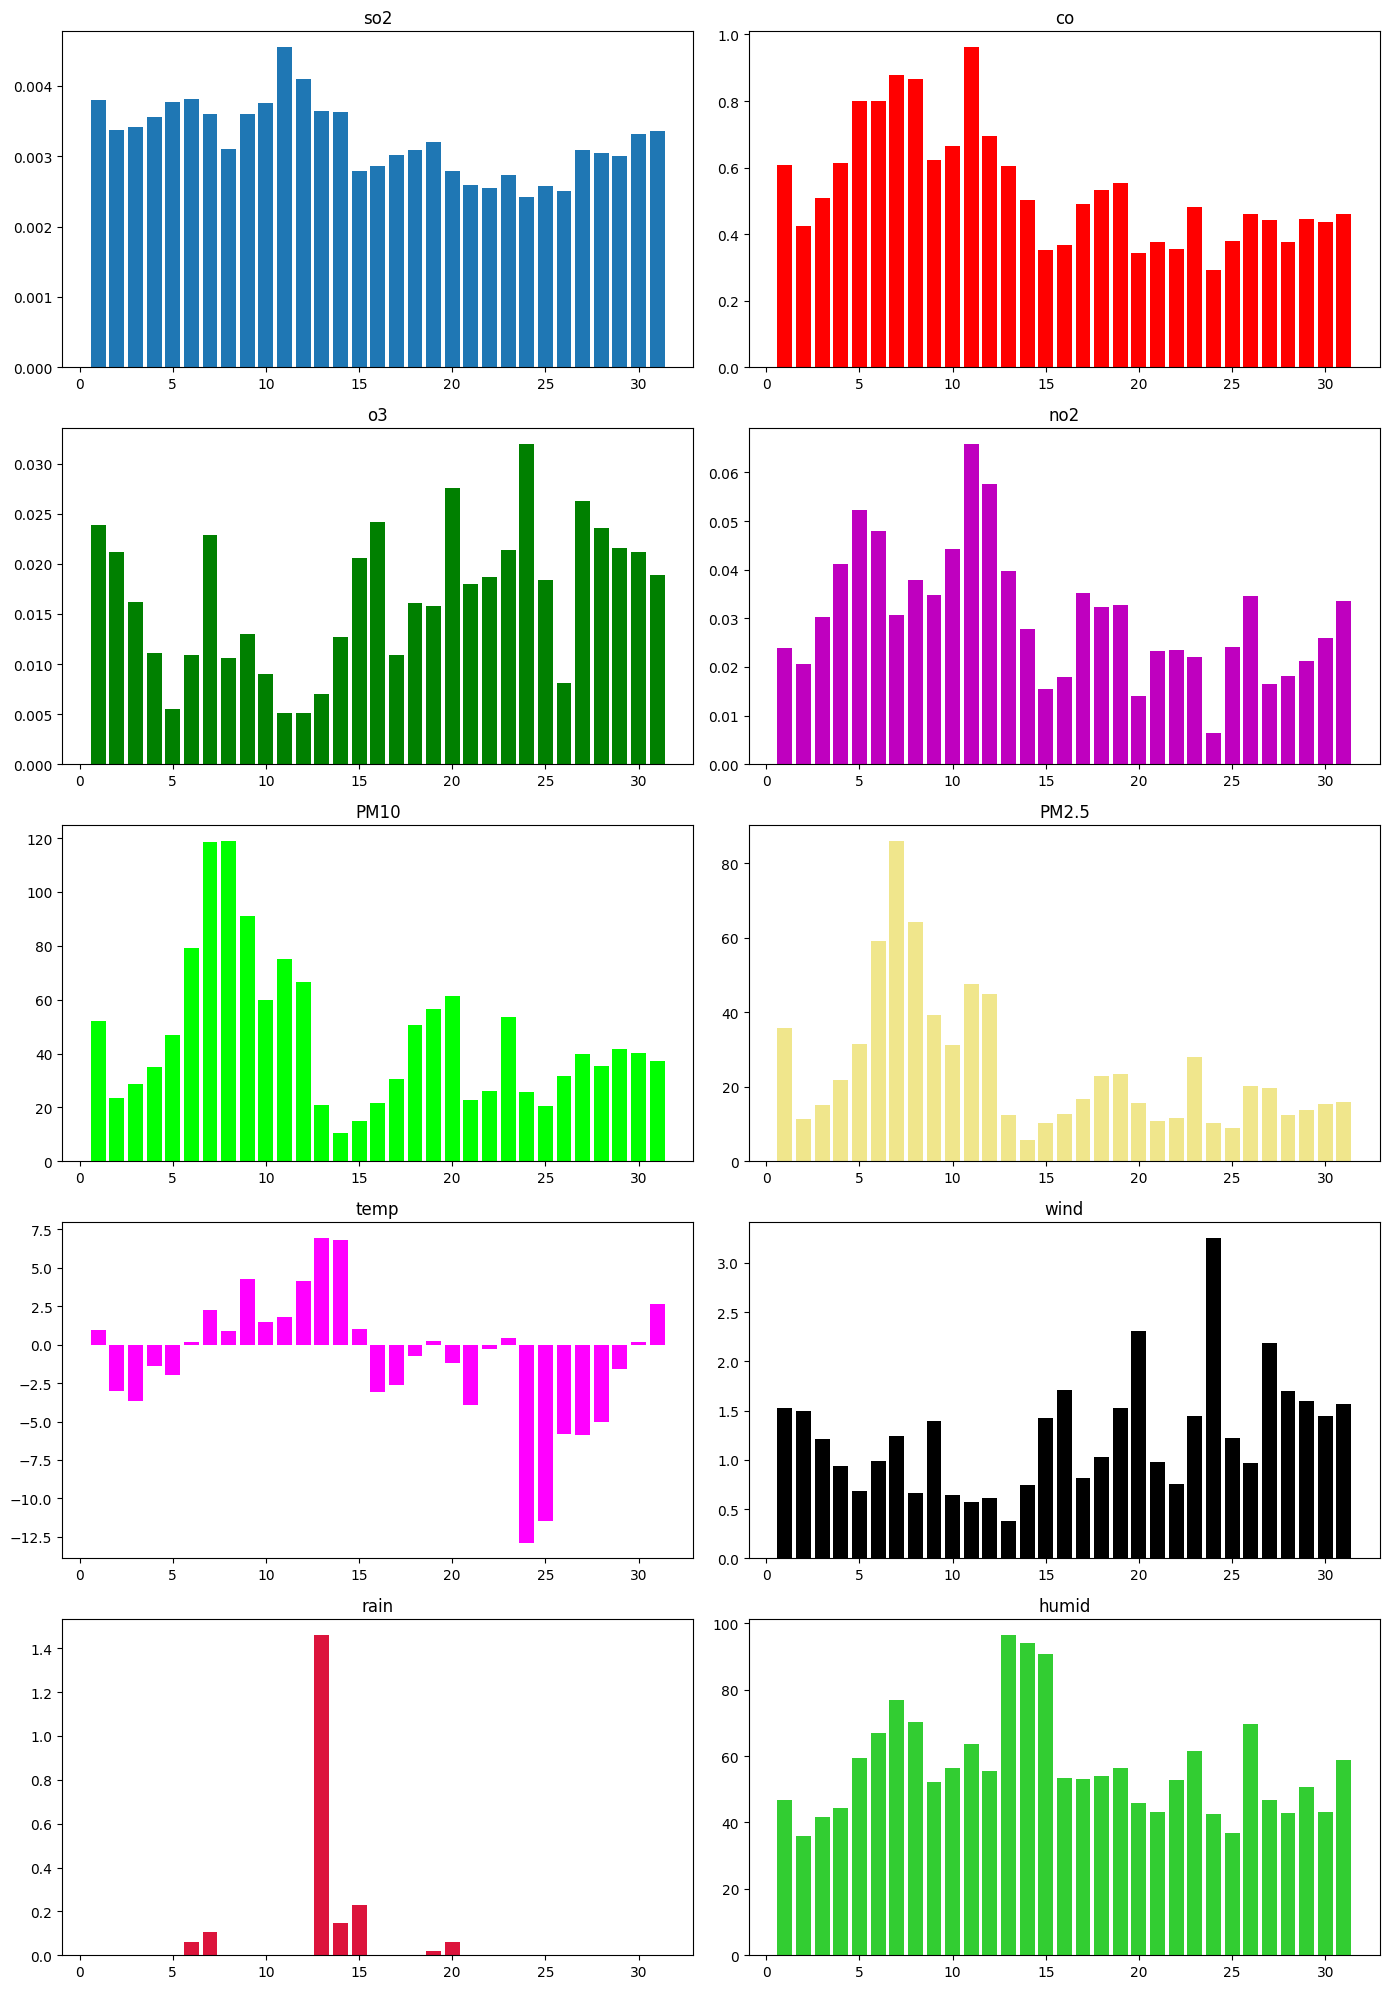

In [43]:
gd = df.groupby(by='day').mean()

fig, ax = plt.subplots(5, 2, figsize=(14, 20))
ax[0, 0].bar(gd.index, gd.so2.values)
ax[0, 0].set_title('so2')
ax[0, 1].bar(gd.index, gd.co.values, color='r')
ax[0, 1].set_title('co')
ax[1, 0].bar(gd.index, gd.o3.values, color='g')
ax[1, 0].set_title('o3')
ax[1, 1].bar(gd.index, gd.no2.values, color='m')
ax[1, 1].set_title('no2')
ax[2, 0].bar(gd.index, gd.PM10.values, color='lime')
ax[2, 0].set_title('PM10')
ax[2, 1].bar(gd.index, gd['PM2.5'].values, color='khaki')
ax[2, 1].set_title('PM2.5')
ax[3, 0].bar(gd.index, gd.temp.values, color='magenta')
ax[3, 0].set_title('temp')
ax[3, 1].bar(gd.index, gd.wind.values, color='k')
ax[3, 1].set_title('wind')
ax[4, 0].bar(gd.index, gd.rain.values, color='crimson')
ax[4, 0].set_title('rain')
ax[4, 1].bar(gd.index, gd.humid.values, color='limegreen')
ax[4, 1].set_title('humid')
plt.tight_layout()
plt.show()

- 외워봅시다 = correlation구하는 법 = 쉽습니다.

In [51]:
corr = df.corr().drop(['year', 'month'], axis=0).drop(['year', 'month'], axis=1) # 요소별 상관관계 구하는 법
corr

,date,day,so2,co,o3,no2,PM10,PM2.5,temp,wind,rain,humid
date,1.000000,0.999480,-0.476949,-0.515899,0.262242,-0.371047,-0.290620,-0.433487,-0.275434,0.276020,-0.043991,-0.123832
day,0.999480,1.000000,-0.482277,-0.512714,0.255085,-0.370469,-0.292039,-0.433847,-0.283777,0.268785,-0.041461,-0.114852
so2,-0.476949,-0.482277,1.000000,0.588337,-0.196315,0.548247,0.381645,0.442252,0.555273,-0.181256,0.003741,0.029518
co,-0.515899,-0.512714,0.588337,1.000000,-0.589383,0.768883,0.620729,0.745347,0.281119,-0.448957,-0.058386,0.353964
o3,0.262242,0.255085,-0.196315,-0.589383,1.000000,-0.840890,-0.063356,-0.181394,-0.071397,0.654250,-0.040538,-0.412117
no2,-0.371047,-0.370469,0.548247,0.768883,-0.840890,1.000000,0.320158,0.435359,0.297442,-0.590997,0.007591,0.255924
PM10,-0.290620,-0.292039,0.381645,0.620729,-0.063356,0.320158,1.000000,0.893680,0.329462,-0.030942,-0.065614,0.083613
PM2.5,-0.433487,-0.433847,0.442252,0.745347,-0.181394,0.435359,0.893680,1.000000,0.301209,-0.162548,-0.047545,0.196176
temp,-0.275434,-0.283777,0.555273,0.281119,-0.071397,0.297442,0.329462,0.301209,1.000000,-0.148674,0.136736,0.223675
wind,0.276020,0.268785,-0.181256,-0.448957,0.654250,-0.590997,-0.030942,-0.162548,-0.148674,1.000000,-0.056842,-0.463221



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


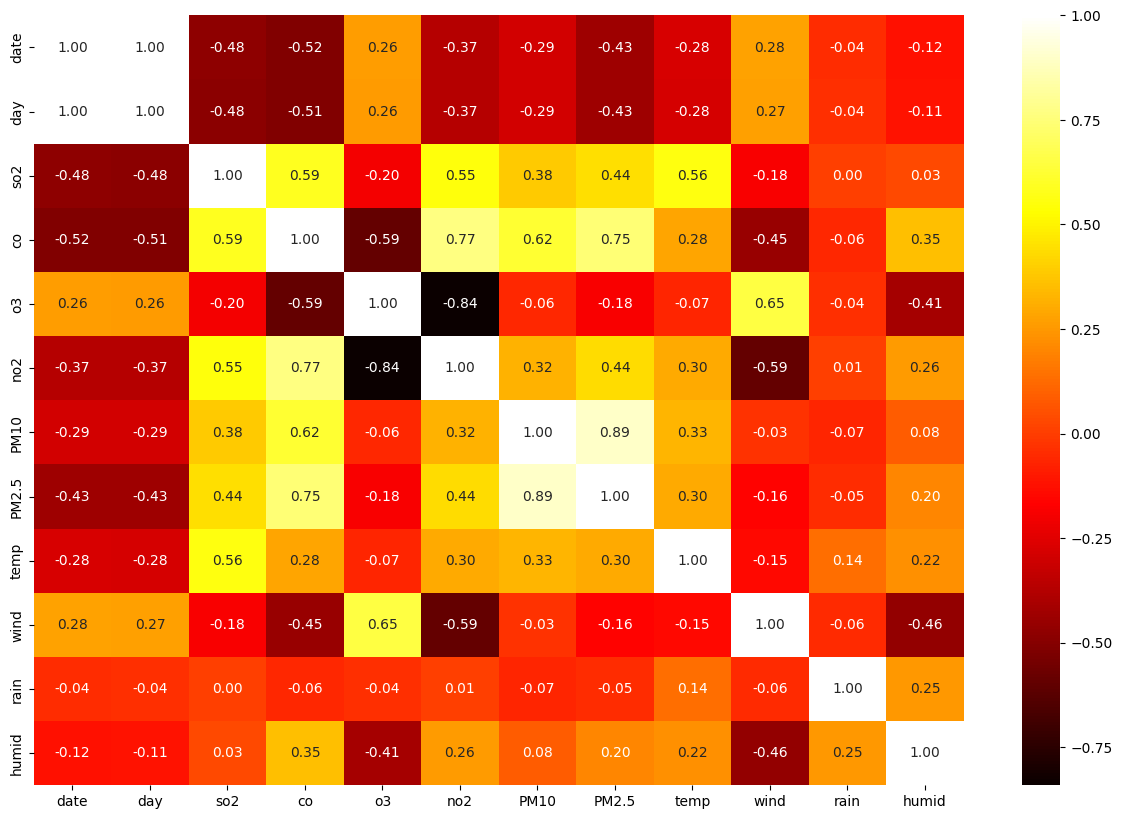

In [55]:
!pip install seaborn
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(data=corr, annot=True, fmt='.2f',cmap='hot');

- no2와 o3는 강한 음의 상관관계, PM10과 PM2.5는 강한 상관관계.

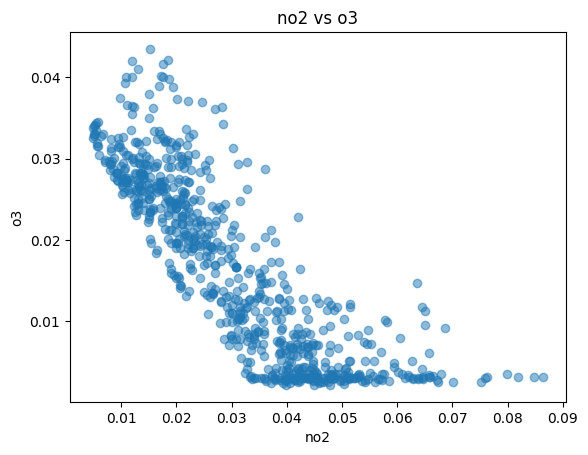

In [56]:
fig, ax = plt.subplots()
ax.scatter(df.no2, df.o3, alpha=0.5)
ax.set_title('no2 vs o3')
ax.set_xlabel('no2')
ax.set_ylabel('o3')
plt.show()

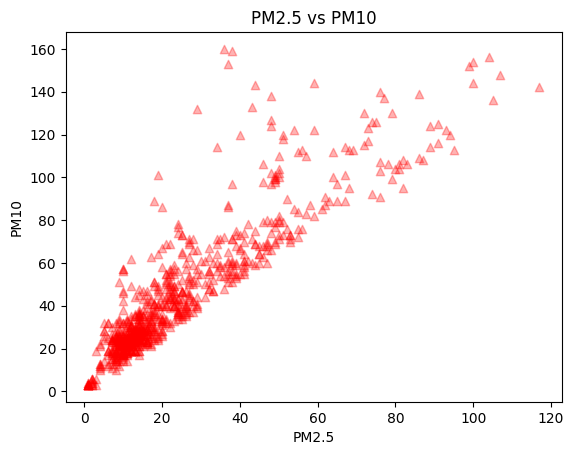

In [61]:
fig, ax = plt.subplots()
ax.scatter(df['PM2.5'], df.PM10, marker='^', color='r', alpha=0.3)
ax.set_title('PM2.5 vs PM10')
ax.set_xlabel('PM2.5')
ax.set_ylabel('PM10')
plt.show()

#######

# 2. 데이터 시각화, 프로젝트 II = 건강 데이터 분석

## a. 건강 데이터 불러오기 🤓
---
- csv 데이터에서 불러오기

In [127]:
hp = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/sat.csv')
hp

,No,시도,구군,삶의 만족도
0,1,서울특별시,종로구,0.4437
1,2,서울특별시,중구,0.4976
2,3,서울특별시,용산구,0.6161
3,4,서울특별시,성동구,0.4729
4,5,서울특별시,광진구,0.4041
...,...,...,...,...
224,225,경상남도,함양군,0.9565
225,226,경상남도,거창군,0.6163
226,227,경상남도,합천군,0.8057
227,228,제주특별자치도,제주시,0.7113


In [128]:
ht = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/health.csv')
ht

,No,시도,구군,평균,주관적 건강수준 인지율,인구 십만명당 정신건강증진기관 수,인구 천명당 의료기관 종사 의사수,건강생활실천율,인구 천명당 의료기관병상수
0,1,서울특별시,종로구,0.9220,0.8424,0.6914,1.0000,0.9697,0.7616
1,2,서울특별시,중구,0.6742,0.5772,0.4106,0.9995,0.9669,0.4043
2,3,서울특별시,용산구,0.5898,0.9819,0.3353,0.6046,0.9844,0.1433
3,4,서울특별시,성동구,0.4794,0.5465,0.3321,0.5783,0.9776,0.2111
4,5,서울특별시,광진구,0.6373,0.8534,0.7393,0.6352,0.8022,0.1936
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.2036,0.0413,0.9857,0.3253,0.1775,0.1068
225,226,경상남도,거창군,0.2150,0.4107,0.4134,0.3705,0.0730,0.4106
226,227,경상남도,합천군,0.2128,0.0360,0.5756,0.3834,0.0320,0.6432
227,228,제주특별자치도,제주시,0.2537,0.4969,0.3854,0.4609,0.2527,0.2240


In [129]:
sf = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/secure.csv')
sf

,No,시도,구군,평균,사회안전에 대한 인식 b),인구 천명당 cctv 대수 b),인구 십만명당 응급의료기관 및 응급실 운영기관수,단위면적당 지역경찰관서 수,지역안전등급 현황 중 '교통사고 및 화재' a)
0,1,서울특별시,종로구,0.7470,0.9965,0.4796,0.7498,0.9998,0.0162
1,2,서울특별시,중구,0.9320,0.9707,0.8214,0.6938,1.0000,0.3014
2,3,서울특별시,용산구,0.5537,0.6641,0.4311,0.1768,0.8923,0.5075
3,4,서울특별시,성동구,0.5347,0.7452,0.4330,0.1562,0.9800,0.3014
4,5,서울특별시,광진구,0.6072,0.7179,0.2196,0.2019,0.9785,0.7117
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.7012,0.7924,0.5686,0.7219,0.3123,0.7117
225,226,경상남도,거창군,0.4392,0.9213,0.3292,0.4718,0.3107,0.3014
226,227,경상남도,합천군,0.4268,0.4158,0.6344,0.6381,0.3080,0.3014
227,228,제주특별자치도,제주시,0.4461,0.3080,0.7366,0.2785,0.3199,0.7117


In [130]:
ev = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/eco.csv')
ev

,No,시도,구군,평균,환경체감도 b),인구 천명당 1일 산업폐수 방류량 a),도시지역 중 '녹지지역 비율',미세먼지(PM2.5) a) b),주민 1인당 생활폐기물배출량 a)
0,1,서울특별시,종로구,0.4637,0.4658,0.7223,0.2012,0.7704,0.0006
1,2,서울특별시,중구,0.2865,0.1077,0.6957,0.0013,0.6617,0.0000
2,3,서울특별시,용산구,0.5030,0.3142,0.7185,0.1349,0.6895,0.4571
3,4,서울특별시,성동구,0.4196,0.1480,0.6868,0.0347,0.3757,0.7426
4,5,서울특별시,광진구,0.4992,0.1229,0.6940,0.0574,0.7235,0.7016
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.7717,0.5959,0.6811,0.7924,0.7620,0.5351
225,226,경상남도,거창군,0.7998,0.9610,0.6259,0.7579,0.7415,0.3901
226,227,경상남도,합천군,0.9117,0.9261,0.6846,0.8187,0.9019,0.5834
227,228,제주특별자치도,제주시,0.6842,0.6287,0.6799,0.7994,0.9016,0.0143


In [131]:
fn = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/financial.csv')
fn

,No,시도,구군,평균,1인당 지역내총생산(GRDP),인구 천명당 사업체수,인구 천명당 종사자수,국민기초생활보장 수급자비율 a),종사자 천명당 영세자영업자 수 a)
0,1,서울특별시,종로구,1.0000,1.0000,1.0000,1.0000,0.7564,0.9037
1,2,서울특별시,중구,0.9806,1.0000,1.0000,1.0000,0.6718,0.9177
2,3,서울특별시,용산구,0.6915,0.6334,0.5493,0.7282,0.7910,0.8341
3,4,서울특별시,성동구,0.6533,0.5132,0.5368,0.6849,0.8243,0.8377
4,5,서울특별시,광진구,0.4445,0.2906,0.3424,0.3870,0.8681,0.7480
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.1401,0.3423,0.5130,0.3566,0.2453,0.0700
225,226,경상남도,거창군,0.1799,0.4873,0.4147,0.3362,0.3372,0.0970
226,227,경상남도,합천군,0.0373,0.3264,0.3722,0.2689,0.1788,0.0064
227,228,제주특별자치도,제주시,0.4250,0.4048,0.5553,0.4624,0.5571,0.5856


In [132]:
ed = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/edu.csv')
ed

,No,시도,구군,평균,교원 1인당 학생수,영유아 천명당 보육시설 수,인구 십만명당 학교수,인구 천명당 사설학원수
0,1,서울특별시,종로구,0.6839,0.8505,0.6248,0.2249,0.8126
1,2,서울특별시,중구,0.5013,0.8729,0.4147,0.2294,0.2944
2,3,서울특별시,용산구,0.2679,0.6479,0.3804,0.1281,0.1629
3,4,서울특별시,성동구,0.2464,0.7661,0.2270,0.1308,0.3366
4,5,서울특별시,광진구,0.4879,0.9309,0.4263,0.1278,0.4607
...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.5064,0.1248,0.2642,0.7779,0.3062
225,226,경상남도,거창군,0.8178,0.5177,0.4380,0.7091,0.5621
226,227,경상남도,합천군,0.1640,0.0475,0.1621,0.9273,0.2386
227,228,제주특별자치도,제주시,0.6468,0.7505,0.4032,0.3291,0.6658


In [133]:
rl = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/relations.csv')
rl

,No,시도,구군,평균,인구 십만명당 자살률 a),1인가구(독거노인 제외) 비율 a),독거노인가구 비율 a),인구 십만명당 사회적기업수,가족관계 만족도 b)
0,1,서울특별시,종로구,0.7425,0.8318,0.0057,0.7593,0.9981,0.5949
1,2,서울특별시,중구,0.4608,0.5462,0.0107,0.7254,1.0000,0.2329
2,3,서울특별시,용산구,0.4317,0.7288,0.0211,0.7754,0.7194,0.2009
3,4,서울특별시,성동구,0.4182,0.7288,0.0791,0.8332,0.6783,0.0937
4,5,서울특별시,광진구,0.3519,0.9434,0.0051,0.8541,0.2461,0.2058
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.2192,0.3443,0.8339,0.0388,0.4276,0.2919
225,226,경상남도,거창군,0.5717,0.3751,0.8630,0.1247,0.9910,0.4271
226,227,경상남도,합천군,0.0510,0.0255,0.8998,0.0076,0.2023,0.3988
227,228,제주특별자치도,제주시,0.6107,0.7249,0.3158,0.7806,0.6912,0.3618


In [134]:
rs = pd.read_csv('https://raw.githubusercontent.com/tysep16/DV25_1/refs/heads/main/res.csv')
rs

,No,시도,구군,평균,여가활용 만족도 b),노인 천명당 노인여가복지시설수,인구 십만명당 도서관수,인구 십만명당 문화기반시설수,인구 천명당 체육관련 여가시설수
0,1,서울특별시,종로구,0.6331,0.8409,0.1573,0.4523,0.9997,0.5559
1,2,서울특별시,중구,0.6691,0.6224,0.1467,0.5369,0.8441,0.9886
2,3,서울특별시,용산구,0.2817,0.6381,0.1628,0.2453,0.3715,0.2934
3,4,서울특별시,성동구,0.3257,0.5657,0.1859,0.3590,0.2768,0.4859
4,5,서울특별시,광진구,0.3313,0.6740,0.1443,0.2333,0.2058,0.6365
...,...,...,...,...,...,...,...,...,...
224,225,경상남도,함양군,0.6758,0.1656,0.9794,0.9257,0.5006,0.5919
225,226,경상남도,거창군,0.4838,0.2433,0.9304,0.4775,0.4135,0.3913
226,227,경상남도,합천군,0.7900,0.1084,0.9748,0.9949,0.6226,0.8836
227,228,제주특별자치도,제주시,0.6948,0.8585,0.2026,0.9455,0.8464,0.3805


## b. 데이터를 병합해보자. 🩰
---
- '시도'를 기준으로 merge --> uniqe 외워보자.

In [135]:
city = list(hp['시도'].unique())
df = pd.DataFrame( {'시도' : city} )
df

,시도
0,서울특별시
1,부산광역시
2,대구광역시
3,인천광역시
4,광주광역시
5,대전광역시
6,울산광역시
7,세종특별자치시
8,경기도
9,강원도


- df에 모든 csv 병합 = gogo

In [136]:
df = pd.merge(df, hp['삶의 만족도'].groupby(by=hp['시도']).mean(), on='시도').rename(columns={'삶의 만족도':'satisfaction'})
df

,시도,satisfaction
0,서울특별시,0.490972
1,부산광역시,0.362081
2,대구광역시,0.363988
3,인천광역시,0.411480
4,광주광역시,0.484480
5,대전광역시,0.407580
6,울산광역시,0.471980
7,세종특별자치시,0.907700
8,경기도,0.426023
9,강원도,0.619506


In [137]:
df = pd.merge(df, ht['평균'].groupby(by=ht['시도']).mean(), on='시도').rename(columns={'평균':'health'})
df

,시도,satisfaction,health
0,서울특별시,0.490972,0.569532
1,부산광역시,0.362081,0.511906
2,대구광역시,0.363988,0.482325
3,인천광역시,0.411480,0.339620
4,광주광역시,0.484480,0.632300
5,대전광역시,0.407580,0.663580
6,울산광역시,0.471980,0.420040
7,세종특별자치시,0.907700,0.232000
8,경기도,0.426023,0.353952
9,강원도,0.619506,0.329506


In [138]:
df = pd.merge(df, sf['평균'].groupby(by=sf['시도']).mean(), on='시도').rename(columns={'평균':'safe'})
df

,시도,satisfaction,health,safe
0,서울특별시,0.490972,0.569532,0.552256
1,부산광역시,0.362081,0.511906,0.404875
2,대구광역시,0.363988,0.482325,0.358429
3,인천광역시,0.411480,0.339620,0.421020
4,광주광역시,0.484480,0.632300,0.266440
5,대전광역시,0.407580,0.663580,0.206780
6,울산광역시,0.471980,0.420040,0.477060
7,세종특별자치시,0.907700,0.232000,0.157800
8,경기도,0.426023,0.353952,0.325255
9,강원도,0.619506,0.329506,0.548000


In [139]:
df = pd.merge(df, ev['평균'].groupby(by=ev['시도']).mean(), on='시도').rename(columns={'평균':'environment'})
df

,시도,satisfaction,health,safe,environment
0,서울특별시,0.490972,0.569532,0.552256,0.470712
1,부산광역시,0.362081,0.511906,0.404875,0.448719
2,대구광역시,0.363988,0.482325,0.358429,0.552500
3,인천광역시,0.411480,0.339620,0.421020,0.515020
4,광주광역시,0.484480,0.632300,0.266440,0.607480
5,대전광역시,0.407580,0.663580,0.206780,0.582380
6,울산광역시,0.471980,0.420040,0.477060,0.393440
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400
8,경기도,0.426023,0.353952,0.325255,0.557977
9,강원도,0.619506,0.329506,0.548000,0.639839


In [140]:
df = pd.merge(df, fn['평균'].groupby(by=fn['시도']).mean(), on='시도').rename(columns={'평균':'financial'})
df

,시도,satisfaction,health,safe,environment,financial
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861


In [141]:
df = pd.merge(df, ed['평균'].groupby(by=ed['시도']).mean(), on='시도').rename(columns={'평균':'education'})
df

,시도,satisfaction,health,safe,environment,financial,education
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260,0.840780
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580,0.763240
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900,0.587000
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926,0.668619
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861,0.488533


In [142]:
df = pd.merge(df, rl['평균'].groupby(by=rl['시도']).mean(), on='시도').rename(columns={'평균':'relation'})
df

,시도,satisfaction,health,safe,environment,financial,education,relation
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412,0.390656
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594,0.294719
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838,0.407486
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920,0.504920
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680,0.637800
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260,0.840780,0.510820
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580,0.763240,0.676440
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900,0.587000,0.673700
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926,0.668619,0.601532
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861,0.488533,0.563122


In [143]:
df = pd.merge(df, rs['평균'].groupby(by=rs['시도']).mean(), on='시도').rename(columns={'평균':'rest'})
df

,시도,satisfaction,health,safe,environment,financial,education,relation,rest
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412,0.390656,0.286732
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594,0.294719,0.153587
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838,0.407486,0.234925
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920,0.504920,0.244590
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680,0.637800,0.454980
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260,0.840780,0.510820,0.347960
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580,0.763240,0.676440,0.418420
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900,0.587000,0.673700,0.447800
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926,0.668619,0.601532,0.377561
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861,0.488533,0.563122,0.632750


In [147]:
df['city'] = ['seoul', 'busan', 'daegu', 'inchon', 'gwangju', 'daejeon', 'ulsan', 'sejong', 'gyunggi', 'gangwon', 'chungbuk', 'chungnam', 'jeonbuk', 'jeonnam', 'gyungbuk', 'gyungnam', 'jeju']
df

,시도,satisfaction,health,safe,environment,financial,education,relation,rest,city
0,서울특별시,0.490972,0.569532,0.552256,0.470712,0.532820,0.399412,0.390656,0.286732,seoul
1,부산광역시,0.362081,0.511906,0.404875,0.448719,0.438038,0.504594,0.294719,0.153587,busan
2,대구광역시,0.363988,0.482325,0.358429,0.552500,0.393975,0.585838,0.407486,0.234925,daegu
3,인천광역시,0.411480,0.339620,0.421020,0.515020,0.410820,0.502920,0.504920,0.244590,inchon
4,광주광역시,0.484480,0.632300,0.266440,0.607480,0.387380,0.689680,0.637800,0.454980,gwangju
5,대전광역시,0.407580,0.663580,0.206780,0.582380,0.416260,0.840780,0.510820,0.347960,daejeon
6,울산광역시,0.471980,0.420040,0.477060,0.393440,0.642580,0.763240,0.676440,0.418420,ulsan
7,세종특별자치시,0.907700,0.232000,0.157800,0.652400,0.511900,0.587000,0.673700,0.447800,sejong
8,경기도,0.426023,0.353952,0.325255,0.557977,0.468926,0.668619,0.601532,0.377561,gyunggi
9,강원도,0.619506,0.329506,0.548000,0.639839,0.386861,0.488533,0.563122,0.632750,gangwon


In [148]:
df.isnull().sum()

시도              0
satisfaction    0
health          0
safe            0
environment     0
financial       0
education       0
relation        0
rest            0
city            0
dtype: int64

## c. 본격 시각화! 😎
---
- 데이터 분석

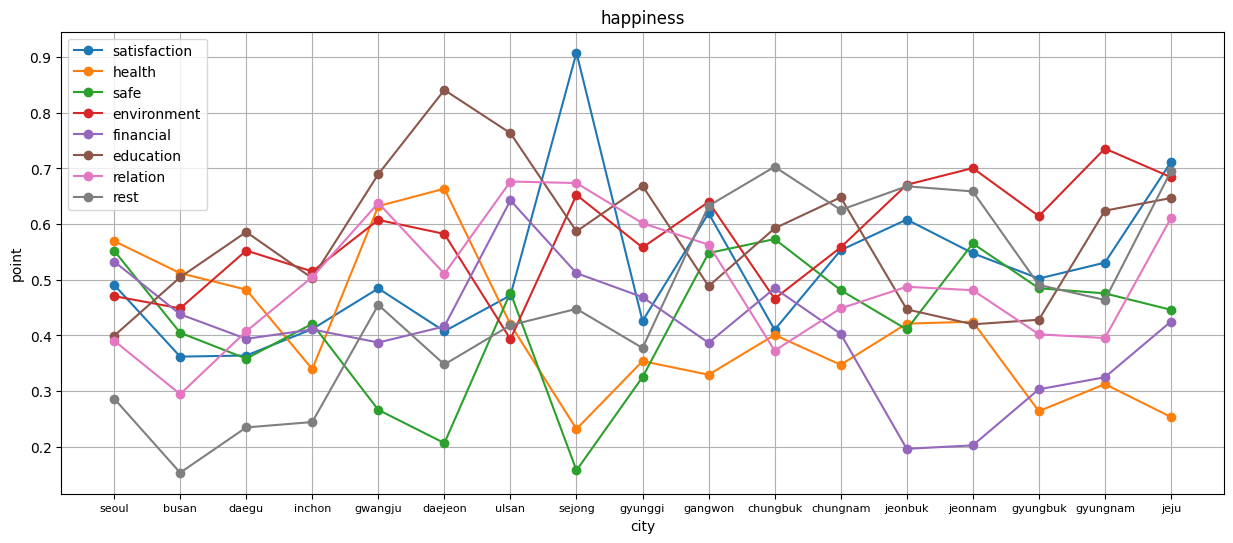

In [150]:
plt.figure(figsize=(15,6))
items = list(df.columns[1:9])
for a in items:
    chartdata = df[a]
    plt.plot(chartdata, marker='o', label=a)

plt.xlabel('city')
plt.ylabel('point')
plt.xticks(range(17), df['city'],fontsize=8)
plt.title('happiness')
plt.legend()
plt.grid()
plt.show()